In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Memory Data Analysis no Arcs

## Frequency of Cards Witout Arcs

In [7]:
mem_df = pd.read_csv("./Data/with_memory_sim_card_frequency.txt")
counts = mem_df.groupby('card_id')['card_frequency'].sum()
arc_ids = counts[counts < 91].index #the highest number an arc card as appear (90)

# Remove esses IDs
mem_df_no_arcs = mem_df[~mem_df['card_id'].isin(arc_ids)]
mem_df_no_arcs.head().style.set_properties(**{'text-align': 'center'})

,run,card_id,card_frequency
0,0,4,6
1,0,48,4
2,0,3,2
3,0,41,5
4,0,43,1


### Card Frequency Max Value By Run

In [41]:
mem_df_max_frequency_no_arcs  = mem_df_no_arcs.groupby('run')['card_frequency'].max().reset_index()

mem_df_max_frequency_no_arcs.head().style.set_properties(**{'text-align': 'center'})

,run,card_frequency
0,0,7
1,1,5
2,2,5
3,3,6
4,4,5


In [43]:
std = mem_df_max_frequency_no_arcs['card_frequency'].std()
print("STD Max Card Frequency:",round(std,3))

STD Max Card Frequency: 0.852


In [45]:
mean = mem_df_max_frequency_no_arcs['card_frequency'].mean()
print("Mean Max Card Frequency:",mean)

Mean Max Card Frequency: 5.61


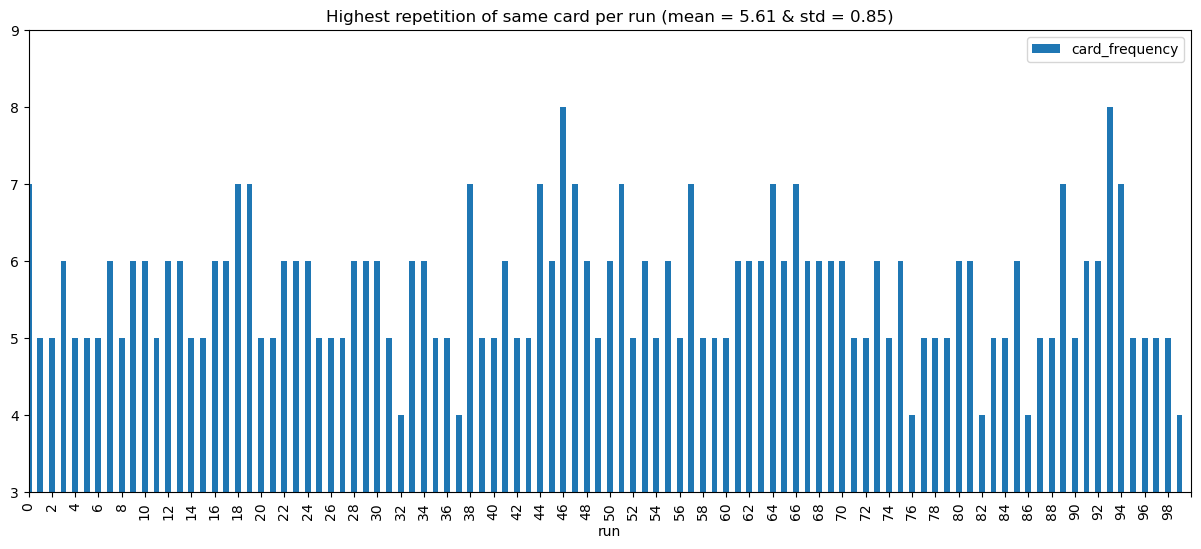

In [47]:
ax = mem_df_max_frequency_no_arcs.plot(
    kind = 'bar', 
    x ='run', 
    y ='card_frequency', 
    figsize = (15, 6), 
    title = (f"Highest repetition of same card per run (mean = {mean:.2f} & std = {std:.2f})")
)
plt.xlim(0,100)
plt.ylim(3,9)

plt.xticks(np.arange(0, 101, step = 2)) # Marcas no X de 10 em 10
plt.yticks(np.arange(3, 10, step = 1))

plt.show()

### Frequency of Max Values

In [55]:
mem_df_max_counts_no_arcs = mem_df_max_frequency_no_arcs['card_frequency'].value_counts().reset_index()
mem_df_max_counts_no_arcs.columns = ['max_repetition', 'frequency'] #rename
mem_df_max_counts_no_arcs = mem_df_max_counts_no_arcs.sort_values(by='max_repetition')

mem_df_max_counts_no_arcs.head()

,max_repetition,frequency
3,4,6
0,5,43
1,6,37
2,7,12
4,8,2


### Mean Frequencies by Run 

In [23]:
mem_df_mean  = mem_df_no_arcs.groupby('run')['card_frequency'].mean().reset_index()
print(mem_df_mean.round(2).head())

   run  card_frequency
0    0            2.42
1    1            2.32
2    2            2.33
3    3            2.42
4    4            2.41


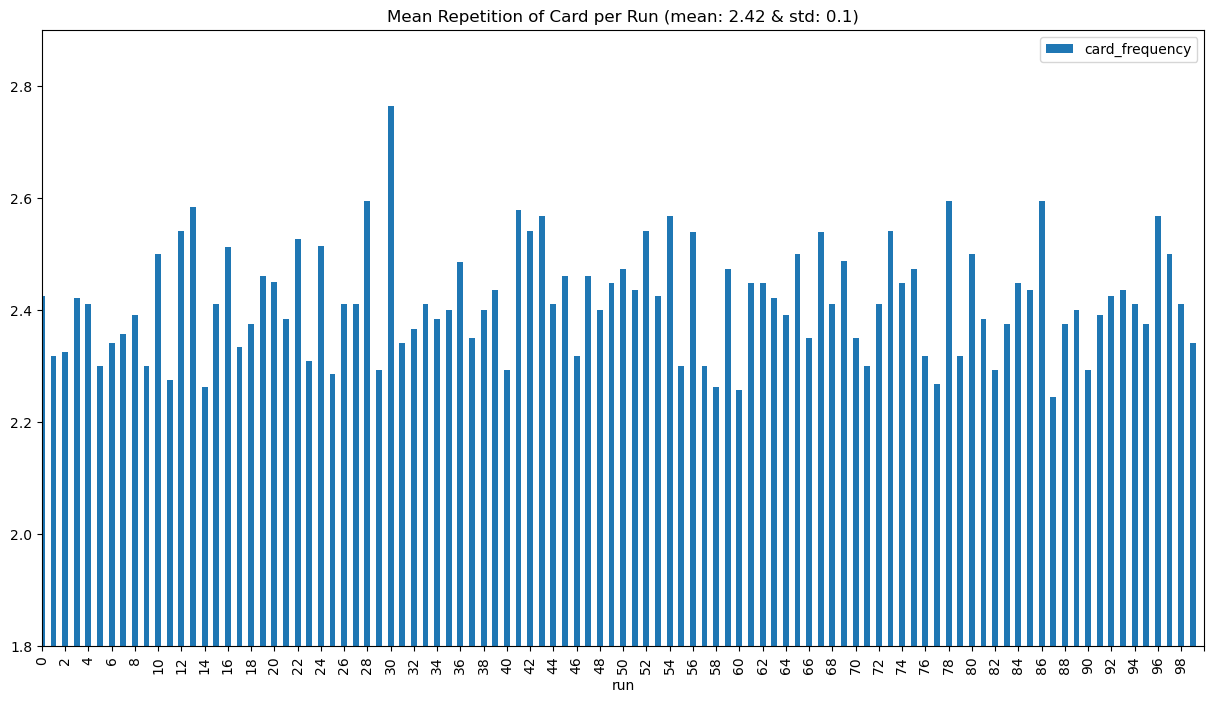

In [25]:
ax = mem_df_mean.plot(
    kind='bar', 
    x='run', 
    y='card_frequency', 
    figsize=(15, 8), 
    title=f"Mean Repetition of Card per Run (mean: {round(mem_df_mean['card_frequency'].mean(),2)} & std: {round(mem_df_mean['card_frequency'].std(),2)})"   
)

plt.xlim(0,99)
plt.ylim(1.8,2.9)

plt.xticks(np.arange(0, 101, step = 2))
plt.yticks(np.arange(1.8, 2.9, step = 0.2))

plt.show()

### Frequency of Cards

In [63]:
mem_df_mean_counts = mem_df_mean['card_frequency'].value_counts().reset_index()
mem_df_mean_counts.columns = ['mean_repetition', 'frequency'] #rename

print(mem_df_mean_counts.round(2).head())

   mean_repetition  frequency
0             2.41         10
1             2.30          5
2             2.45          5
3             2.50          4
4             2.32          4


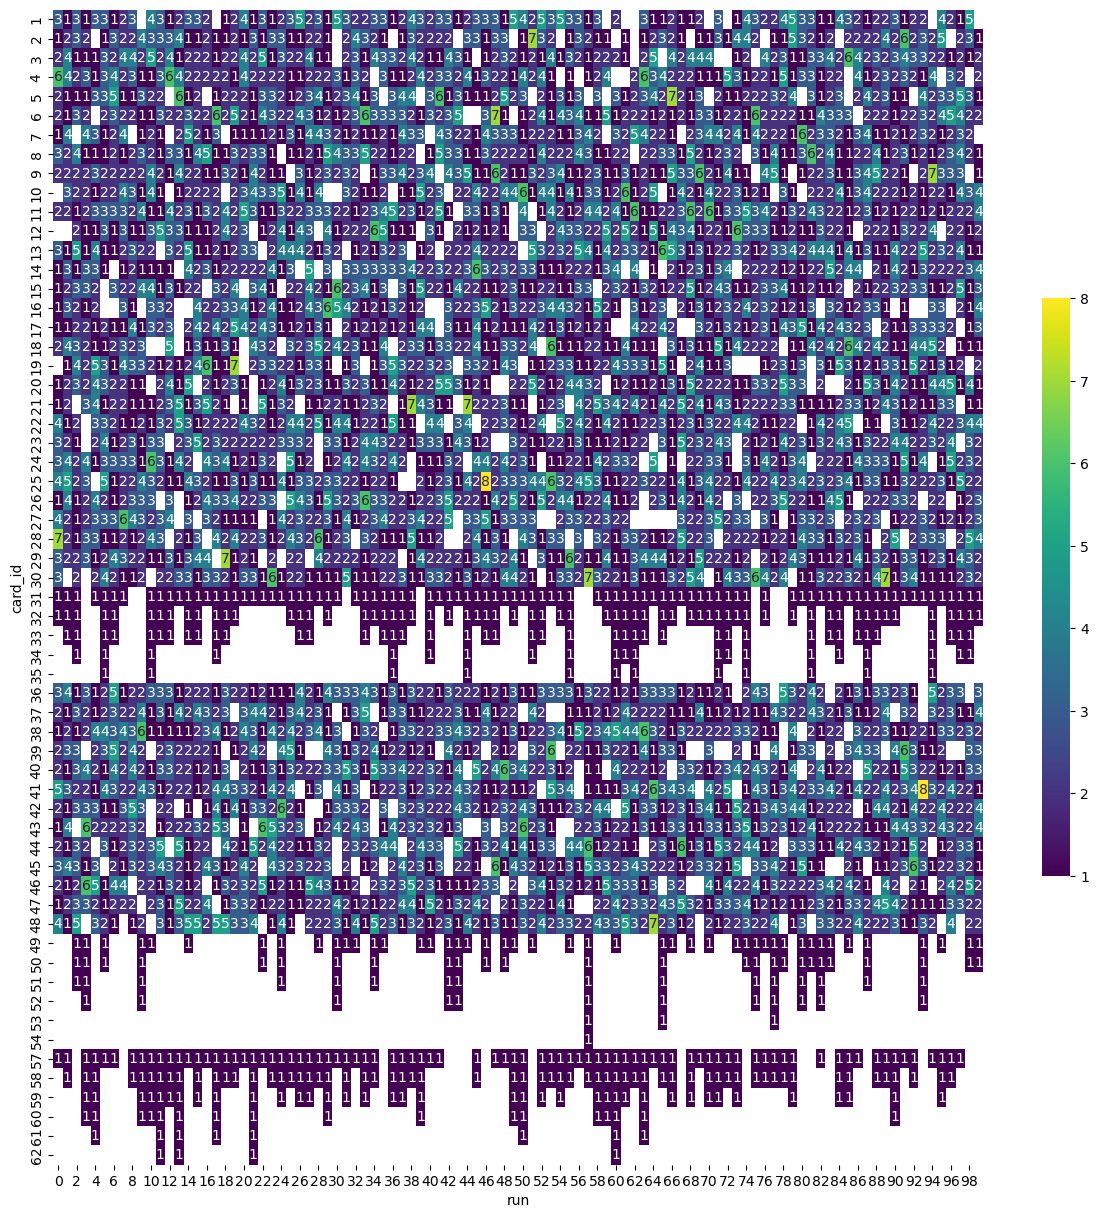

In [65]:
plt.figure(figsize=(15,15))

result = mem_df.pivot(index='card_id', columns='run', values='card_frequency')
sns.heatmap(result, annot=True, fmt="g", cmap='viridis',cbar_kws={"shrink": 0.5},)

plt.show()

### Amount of Times a Card is Displayed in 100 Runs

In [71]:
mem_df_total_card_count =  mem_df_no_arcs.groupby('card_id')['card_frequency'].sum().reset_index()
mem_df_total_card_count.columns = ['card_id', 'card_count'] #rename

mem_df_total_card_count.head()
mem_df_total_card_count.tail()

,card_id,card_count
38,44,231
39,45,217
40,46,218
41,47,219
42,48,230


In [75]:
std = mem_df_total_card_count['card_count'].std()
mean = mem_df_total_card_count['card_count'].mean()

print("STD  Card Count:",round(std,3))
print("Mean Card Count:",round(mean,3))

STD  Card Count: 12.035
Mean Card Count: 219.907


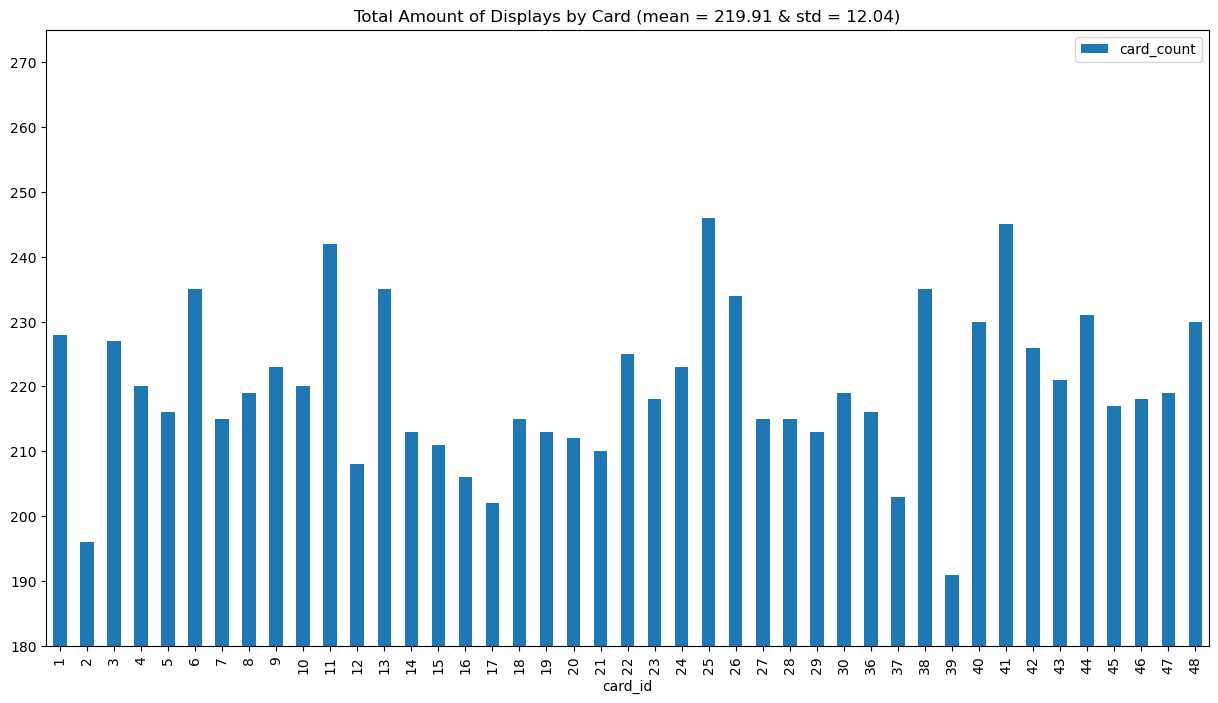

In [77]:
ax = mem_df_total_card_count.plot(
    kind='bar', 
    x='card_id', 
    y='card_count', 
    figsize=(15, 8), 
    title=(f"Total Amount of Displays by Card (mean = {mean:.2f} & std = {std:.2f})")
)

plt.ylim(180,275)
#plt.xlim(0,48)

#plt.xticks(np.arange(0, 48, step = 1))
plt.yticks(np.arange(180, 275, step = 10))

plt.show()

### Average Card Display Times

In [81]:
mem_no_arc_df_total_card_count =  mem_df_no_arcs.groupby('card_id')['card_frequency'].sum().reset_index()
mem_no_arc_df_total_card_count.columns = ['card_id', 'card_count'] #rename
mem_no_arcs_df_average_card_count = mem_no_arc_df_total_card_count
mem_no_arcs_df_average_card_count["card_count_real_mean"] = mem_no_arc_df_total_card_count["card_count"]/100 #média real != mean(média das runs em que aparece)

print(mem_no_arcs_df_average_card_count.head())


   card_id  card_count  card_count_real_mean
0        1         228                  2.28
1        2         196                  1.96
2        3         227                  2.27
3        4         220                  2.20
4        5         216                  2.16


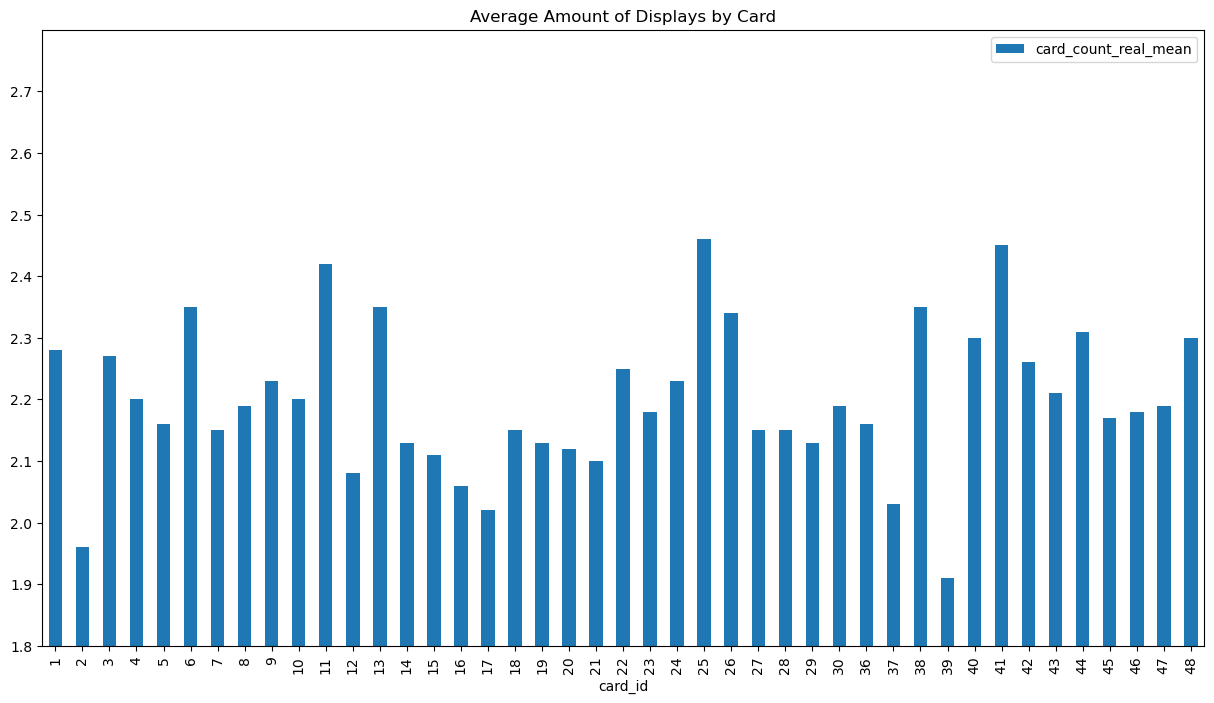

In [85]:
ax = mem_no_arcs_df_average_card_count.plot(
    kind='bar', 
    x ='card_id', 
    y ='card_count_real_mean', 
    figsize = (15, 8), 
    title = "Average Amount of Displays by Card"   
)
plt.ylim(1.8,2.8)
plt.yticks(np.arange(1.8, 2.8, step = 0.1))

plt.show()

### Mean Card Display Times and Presence %


In [9]:
# 1. MÉDIA GLOBAL (Média de 'presença' em 100 runs)
# Se der 1.0, significa que em média vês 1 carta destas por run (total de 100 em 100 runs)
mean_global = mem_df_no_arcs.groupby('card_id')['card_frequency'].sum() / 100

# 2. MÉDIA DE INTENSIDADE (Média de 'amontoado' quando aparece)
# Se a carta aparece 100 vezes num só run e 0 nos outros 99, este valor será 100!
mean_intensity = mem_df_no_arcs.groupby('card_id')['card_frequency'].mean()

# 3 Em quantos runs (dos 100) a carta apareceu?
presence_count = mem_df_no_arcs.groupby('card_id')['run'].nunique()
presence_percentage = (presence_count / 100) * 100

# Criar o DF para comparar
df_compare = pd.DataFrame({
    'Presence (%)': presence_percentage,
    'Global (Espalhado)': mean_global,
    'Intensidade (Concentrado)': mean_intensity
    
})
print(df_compare.round(2).head())


         Presence (%)  Global (Espalhado)  Intensidade (Concentrado)
card_id                                                             
1                91.0                2.28                       2.51
2                88.0                1.96                       2.23
3                93.0                2.27                       2.44
4                92.0                2.20                       2.39
5                89.0                2.16                       2.43


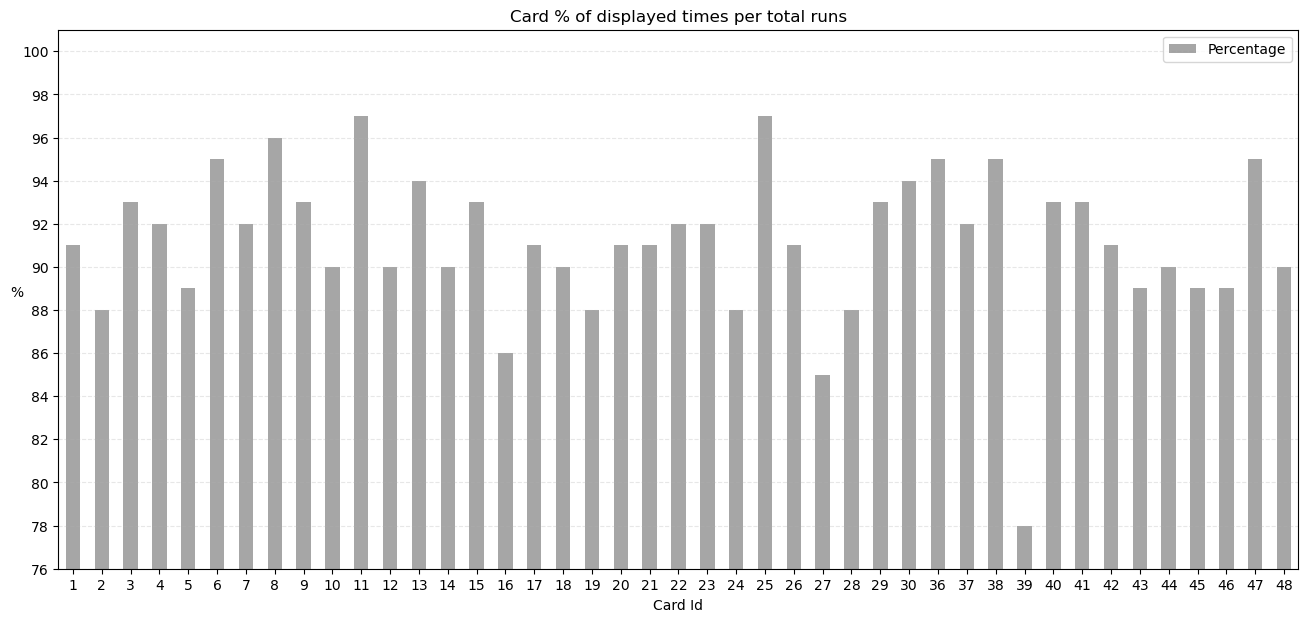

In [27]:
plt.figure(figsize=(16, 7))
ax = presence_percentage.plot(kind = 'bar', color='black', alpha=.35, label='Percentage')

plt.title("Card % of displayed times per total runs")
plt.ylim(76,101)
plt.yticks(np.arange(76, 101, step = 2))

plt.xticks(range(len(mean_global)), mean_global.index, rotation=0)
plt.xlabel("Card Id")
plt.ylabel("%", rotation=0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


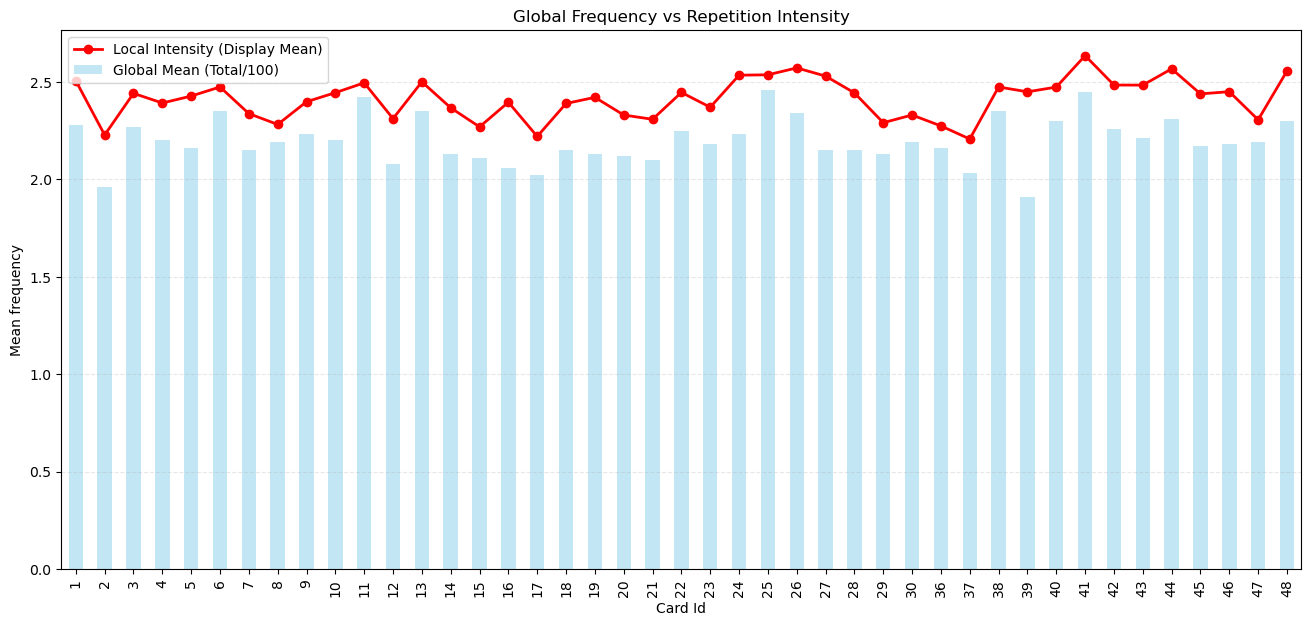

In [294]:
# 1. Garante que ambos têm exatamente os mesmos IDs (o reindex resolve o "salto")
mean_intensity = mean_intensity.reindex(mean_global.index)

plt.figure(figsize=(16, 7))

# 2. Desenha as barras e guarda o objeto 'ax'
ax = mean_global.plot(kind='bar', color='skyblue', alpha=0.5, label='Global Mean (Total/100)')

# 3. TRUQUE: Usa os números das posições (0, 1, 2...) para a linha bater certo com as barras
plt.plot(range(len(mean_intensity)), mean_intensity.values, 
         marker='o', color='red', label='Local Intensity (Display Mean)', linewidth=2)

plt.title("Global Frequency vs Repetition Intensity")
plt.xticks(range(len(mean_global)), mean_global.index, rotation=90)
plt.xlabel("Card Id")
plt.ylabel("Mean frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


## Run Summary Data Analysis ( Not Relevant = With_Memory )

In [89]:
mem_no_arcs_df1_original = pd.read_csv("./Data/with_memory_sim_summary.txt", index_col=0)

### Mean Values & Standart Deviation

In [3]:
df1 = pd.read_csv("./Data/with_memory_sim_summary.txt")
df1.head().style.set_properties(**{'text-align': 'center'})

,run,unique_cards,repetitions,final_wealth,final_morale,final_stability,final_progress
0,0,43,57,-200,235,25,500
1,1,46,54,-200,370,0,345
2,2,47,53,-55,305,30,460
3,3,46,54,30,255,-10,325
4,4,45,55,-40,245,-25,340


In [5]:
mem_no_arc_df1_mean_wv = df1.drop(['run', 'repetitions'], axis = 1).mean()
mem_no_arc_df1_mean_wv['Std'] = df1['unique_cards'].std()
mem_no_arc_df1_mean_wv = mem_no_arc_df1_mean_wv.loc[['unique_cards','Std','final_wealth','final_morale', 'final_stability','final_progress']] 

In [7]:
print(mem_no_arc_df1_mean_wv.round(2))

unique_cards        44.63
Std                  2.15
final_wealth      -125.40
final_morale       308.50
final_stability      0.10
final_progress     372.00
dtype: float64


### Absolute Card  Variance

In [ ]:
mem_no_cards_unique_card_mean = df1['unique_cards'].mean()
df1['Mean Dev'] = df1['unique_cards'] - mem_no_cards_unique_card_mean

col_deviation = df1.pop('Mean Dev')
df1.insert(2, 'Mean Dev', col_deviation)

df1 = df1.drop(['run', 'repetitions'], axis = 1)

In [99]:
df1.head().style.set_properties(**{'text-align': 'center'}).format(precision=2)

,run,unique_cards,repetitions,final_wealth,final_morale,final_stability,final_progress
0,0,43,57,-200,235,25,500
1,1,46,54,-200,370,0,345
2,2,47,53,-55,305,30,460
3,3,46,54,30,255,-10,325
4,4,45,55,-40,245,-25,340


### Absolute World Values Variance

In [368]:
wealth_mean = df1['final_wealth'].mean()
moral_mean = df1['final_morale'].mean()
stability_mean = df1['final_stability'].mean()
progress_mean = df1['final_progress'].mean()

# Usamos .abs() se quiseres apenas a distância, ou deixamos sem se quiseres valores positivos/negativos
df1['wlt_dv'] = df1['final_wealth'] - wealth_mean
df1['moral_dv'] = df1['final_morale'] - moral_mean
df1['stab_dv'] = df1['final_stability'] - stability_mean
df1['prog_dv'] = df1['final_progress'] - progress_mean

In [370]:
df1 = df1[['unique_cards','Mean Dev','final_wealth','wlt_dv','final_morale','moral_dv','final_stability', 'stab_dv','final_progress','prog_dv']]

In [372]:
print(f"Means: Wealth: {wealth_mean:.2f} | Moral: {moral_mean:.2f} | Stability: {stability_mean:.2f} | Progress: {progress_mean:.2f}") 

Means: Wealth: -125.40 | Moral: 308.50 | Stability: 0.10 | Progress: 372.00


In [374]:
df1.head().style.set_properties(**{'text-align': 'center'}).format(precision=2)

,unique_cards,Mean Dev,final_wealth,wlt_dv,final_morale,moral_dv,final_stability,stab_dv,final_progress,prog_dv
0,43,-1.63,-200,-74.60,235,-73.50,25,24.90,500,128.00
1,46,1.37,-200,-74.60,370,61.50,0,-0.10,345,-27.00
2,47,2.37,-55,70.40,305,-3.50,30,29.90,460,88.00
3,46,1.37,30,155.40,255,-53.50,-10,-10.10,325,-47.00
4,45,0.37,-40,85.40,245,-63.50,-25,-25.10,340,-32.00


### World Variables Standart Deviation Graph


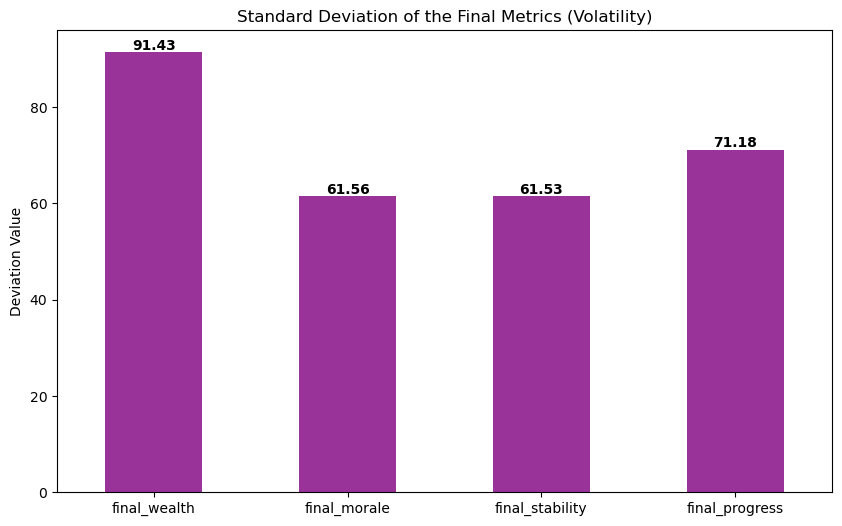

In [9]:
# Selecionar as colunas de métricas do Ficheiro 3 (Sumário)
metricas = ['final_wealth', 'final_morale', 'final_stability', 'final_progress']
std_values = df1[metricas].std()

# Plot
std_values.plot(kind='bar', figsize=(10, 6), color='purple', alpha=0.8)
plt.title("Standard Deviation of the Final Metrics (Volatility)")
plt.ylabel("Deviation Value")
plt.xticks(rotation=0)

# Adicionar os valores por cima das barras para leitura fácil
for i, v in enumerate(std_values):
    plt.text(i, v + 0.5, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


### Graphs Card Variation to mean


In [139]:
std = mem_no_arcs_df1_original['unique_cards'].std()
print("STD card variation to mean:",round(std,2))

STD card variation to mean: 2.15


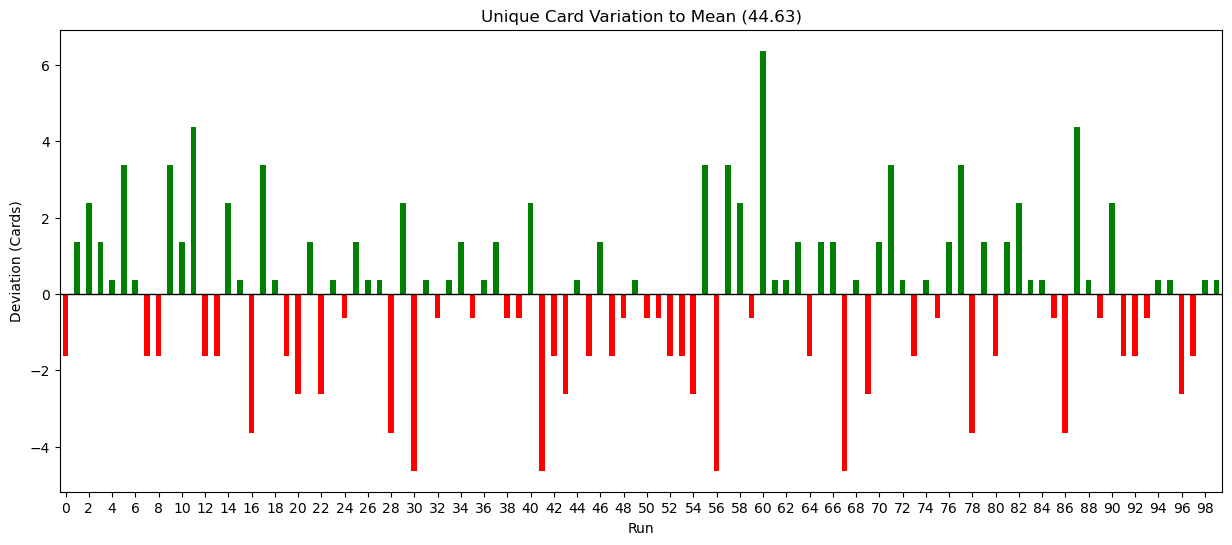

In [243]:
# 1. Calcular o desvio (como fizemos antes)
media = df1['unique_cards'].mean()
df1['Desvio'] = df1['unique_cards'] - media
# 2. Definir as cores com base no valor (Positivo = Verde, Negativo = Vermelho)
cores = ['green' if x > 0 else 'red' for x in df1['Desvio']]

# 3. Criar o gráfico
plt.figure(figsize=(15, 6))
df1['Desvio'].plot(kind='bar', color=cores)

plt.xticks(np.arange(0, 100, step = 2))
plt.xticks(rotation = 0)

plt.axhline(0, color='black', linewidth=1) # Linha do zero (a média)
plt.title(f"Unique Card Variation to Mean ({media:.2f})")
plt.xlabel("Run")
plt.ylabel("Deviation (Cards)")
plt.show()

## Logs Analysis

### Card Exhaustion Graph

In [9]:
mem_no_arcs_df_logs = pd.read_csv("./Data/with_memory_sim_log.txt")#, index_col=0)

In [13]:
arc_ids = [31,32,33,34,35,49,50,51,52,53,54,55,56,57,58,59,60,61,62]

# Remove esses IDs
mem_no_arcs_df_logs = mem_no_arcs_df_logs[~mem_no_arcs_df_logs['card_id'].isin(arc_ids)].reset_index(drop=True)

mem_no_arcs_df_logs.head().style.set_properties(**{'text-align': 'center'})

,run,turn,card_id,choice,wealth,morale,stability,progress,is_new,cards_discovered
0,0,0,4,0,35,65,50,50,True,1
1,0,1,48,1,35,65,50,50,True,2
2,0,2,3,0,50,65,45,50,True,3
3,0,3,41,0,40,80,45,50,True,4
4,0,4,43,0,60,80,35,50,True,5


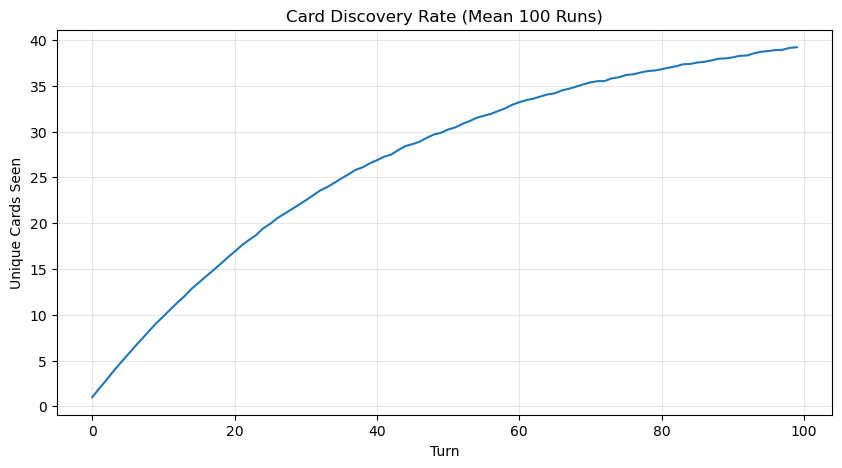

In [19]:
df_newcard_rate = mem_no_arcs_df_logs
# 1. Criar uma coluna que marca se a carta é nova naquele run
df_newcard_rate['is_new'] = df_newcard_rate.groupby('run')['card_id'].transform(lambda x: ~x.duplicated())

# 2. Somar cumulativamente as cartas novas por run
df_newcard_rate['cards_discovered'] = df_newcard_rate.groupby('run')['is_new'].cumsum()

# 3. Tirar a média de descoberta de todos os runs por turno
df_newcard_rate = df_newcard_rate.groupby('turn')['cards_discovered'].mean()

# Plot
df_newcard_rate.plot(figsize=(10, 5), title="Card Discovery Rate (Mean 100 Runs)")
plt.xlabel("Turn")
plt.ylabel("Unique Cards Seen")
plt.grid(True, alpha=0.3)
plt.show()


### Recurrence Index (Distância entre a mesma carta)


Distância média entre a mesma carta: 25.95 turnos
Mínima distância registada: 5.0 turnos


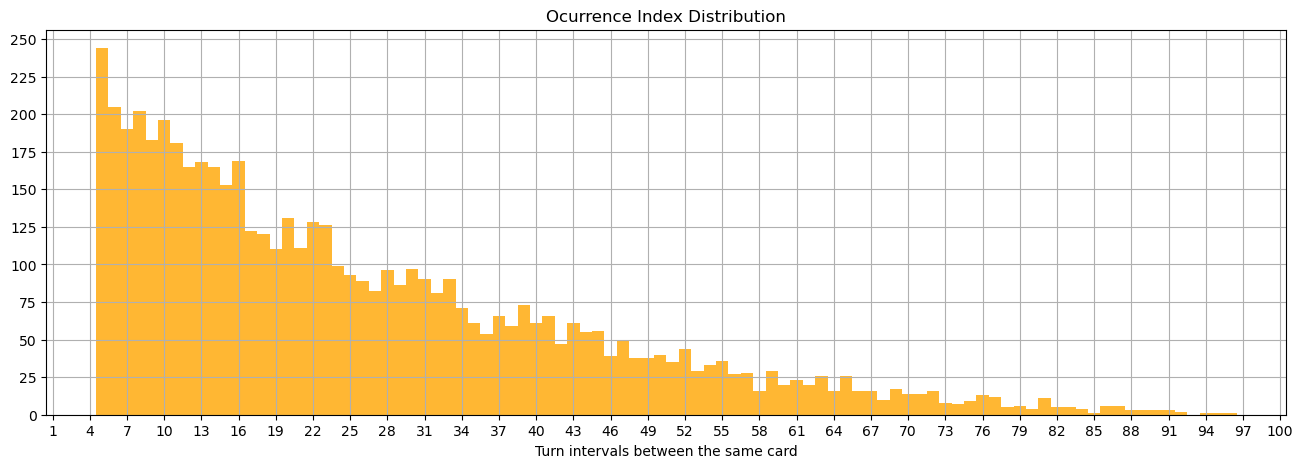

In [71]:
df_recurrence = mem_no_arcs_df_logs

# Calcular a distância (diff) entre turnos para o mesmo card_id dentro de cada run
df_recurrence = df_recurrence.sort_values(['run', 'turn'])
df_recurrence['distancia_recorrencia'] = df_recurrence.groupby(['run', 'card_id'])['turn'].diff()

# Filtrar NaN (primeira aparição não tem distância)
df_recurrence = df_recurrence['distancia_recorrencia'].dropna()

print(f"Distância média entre a mesma carta: {df_recurrence.mean():.2f} turnos")
print(f"Mínima distância registada: {df_recurrence.min()} turnos")

plt.figure(figsize=(16, 5))
bins_inteiros = np.arange(0.5, 101.5, 1)
df_recurrence.hist(bins = bins_inteiros, color = 'orange' , alpha=0.8, edgecolor='none')

# Força os ticks do X a baterem certo com as barras
plt.xlim(0.5, 100.5)

plt.title("Ocurrence Index Distribution")#Distribuição do Índice de Recorrência")
plt.xlabel("Turn intervals between the same card")# Turnos de intervalo entre a mesma carta")
plt.xticks(np.arange(1, 101, step = 3))
plt.yticks(np.arange(0, 275, step = 25))

plt.show()
